# Do Sheaf Neural Networks Use Their Geometry? A Holonomy Audit of Learned Restriction Maps

**Team Sheafu** · Topological Deep Learning Challenge 2026, Track 1

This executable submission audits learned sheaf restriction maps. The
companion paper, *Measuring Triangle Holonomy in Sheaf Neural Networks*
([arXiv:2607.19514](https://arxiv.org/abs/2607.19514)), gives the longer argument.

**Finding in one line.** Learned sheaf geometry is *recruited, then required,
but never cycle-functional* in these experiments.

The audit composes learned edge transports around every triangle and reports
three gauge-invariant quantities: *twist*, *gain*, and *flip*. Triangle
counting recruits roughly forty-fold $SO(2)$ twist; community detection does
not. At first, a ridge on seven degree statistics wins six-fold and flattening
is unresolved. With one hundred times more data, flattening is catastrophic,
yet fixed-degree graphs defeat every model at every scale. All experiments run
on CPU; the instrument is unit-tested.

## How to use and reproduce

The committed notebook is fully executed. To rerun it, use Python 3.11 and
`pip install -e .` on this TopoBench branch.

Every number, table, and figure is recomputed from committed `*_results.json`
files; no training or GPU is needed. Plotting and statistics require
`numpy`, `pandas`, `scipy`, and `matplotlib`. The instrument self-check and
configuration cells import `torch` and `torch_geometric`; CPU builds suffice.
Scripts listed near the end regenerate the JSON files.

## Part I - Main analysis

## 1&ensp;Research question

Sheaf neural networks (Hansen & Gebhart, 2020; Bodnar et al., 2022) attach a
stalk to each node and a learnable restriction map to each edge. Orthogonal
maps induce discrete parallel transport (Singer & Wu, 2012; Barbero et al.,
2022). Its product around a cycle need not be the identity. This holonomy
could expose cycles beyond 1-WL message passing, which cannot count connected
induced patterns on three or more nodes, including triangles (Chen et al.,
2020; Morris et al., 2019).

This geometry is usually unmeasured. Identity restrictions already match
learned sheaves on standard benchmarks (Hernández Caralt et al., 2026).
**Does a trained sheaf model bend; if so, when, and does it matter?**

We ask: **Q1 (existence):** does a
trained model develop holonomy at all? **Q2 (task-shaping):** does holonomy
appear specifically when the task rewards cycle sensitivity? **Q3
(function):** is it causally load-bearing? GraphUniverse (Van Langendonck et
al., 2026) supplies triangle counting and a smoothing-solvable community
control.

**Contributions.** (i) A per-cycle audit with three
conjugation-invariant readouts (twist, gain, flip) derived from the polar
decomposition, proved and verified to machine precision. (ii) Unit-tested
transport capture inside TopoBench (Telyatnikov et al., 2025). (iii) 460
controlled runs separating recruitment, dependence, and cycle function.

## 2&ensp;Setting

### 2.1&ensp;Datasets and data-generating process

Graphs are drawn from GraphUniverse (Van Langendonck et al., 2026), the
challenge's DC-SBM-based generator. This probe grid is deliberately
triangle-dense and distinct from the official 12-regime evaluation grid.

| Component | Configuration |
|---|---|
| GraphUniverse | $K=20$; feature dimension 15; centre variance 0.2; cluster variance 0.4; edge-propensity variance 1.0 |
| Probe family | 100–160 nodes; 5–7 communities; average degree 5–7; power-law exponent 2.0–2.5; degree separation 0.5–1.0 |
| Homophily | high $[0.9,1.0]$; low $[0.0,0.1]$ |
| Split and seeds | 30 training / 8 test graphs; 10 independent seeds for the high-homophily primary analyses, 3 for the original low-homophily arm |
| Random regular probe | $(n,r)=(100,6)$; Gaussian identifiers and constant features; the same 30/8 budget; 10 seeds in the controls batch |

Each seed resamples both the data family and initialisation. The tasks are
graph-level triangle counting and node-level community detection. The scaling
arm uses 3 seeds and
$N_{\mathrm{train}} \in \{30,100,300,1000,3000\}$.

### 2.2&ensp;Models, baselines, and metrics

| Item | Definition |
|---|---|
| Dynamics | NSP wave dynamics and NSD diffusion |
| Restriction maps | diagonal, bundle ($SO(2)$), and general full $2 \times 2$ maps |
| Encoder | 2 layers, stalk dimension $d=2$, 32 hidden units |
| Constant baseline | per-split constant predictor fitted on the training split |
| Degree baseline | ridge regression on seven degree-sequence summaries: node and edge counts and degree moments |
| Triangle metric | MSE on targets standardised after $\log(1+y)$ on the training split |
| Community metric | accuracy; training uses cross-entropy |

The two architectures share the sheaf-learning machinery and differ only in
dynamics. NSD is the discrete sheaf diffusion of Bodnar et al. (2022),
$$X_{t+1} = X_t - \sigma\!\big(\Delta_{\mathcal{F}}\,(I_n \otimes W_1)\, X_t\, W_2\big),$$
and NSP is a leapfrog discretisation of the sheaf wave equation,
$$X_{t+1} = 2X_t - X_{t-1} - h^2\, \sigma\!\big(\Delta_{\mathcal{F}}\,(I_n \otimes W_1)\, X_t\, W_2\big),$$
with step size $h$. A local MLP predicts each edge restriction map. Task heads
are a per-node linear classifier and mean-pool plus linear regression.

### 2.3&ensp;Sheaf notation

**Notation.** Let $G = (V, E)$ be an undirected graph, $n = \lvert V \rvert$.
Node features are $X \in \mathbb{R}^{n \times f}$. A cellular sheaf attaches a
*stalk* $\mathcal{F}(v) \cong \mathbb{R}^d$ to each node and
$\mathcal{F}(e) \cong \mathbb{R}^d$ to each edge; $d$ is the stalk dimension.
We write $I$ for the identity and $\operatorname{tr}$ for the trace.

**Definition 2.1** (Cellular sheaf; Hansen & Ghrist, 2019). A cellular sheaf
$\mathcal{F}$ on $G$ assigns to every incident node–edge pair $v \trianglelefteq e$
a linear *restriction map* $F_{v \trianglelefteq e} : \mathcal{F}(v) \to \mathcal{F}(e)$.

**Definition 2.2** (Sheaf Laplacian). The sheaf Laplacian
$\Delta_{\mathcal{F}} \in \mathbb{R}^{nd \times nd}$ is the positive
semi-definite block matrix with diagonal blocks
$\Delta_{vv} = \sum_{v \trianglelefteq e} F_{v \trianglelefteq e}^{\top} F_{v \trianglelefteq e}$
and off-diagonal blocks
$\Delta_{uv} = -F_{u \trianglelefteq e}^{\top} F_{v \trianglelefteq e}$ for
$e = (u, v)$ (Hansen & Ghrist, 2019; Bodnar et al., 2022).

**Definition 2.3** (Edge transport). For an edge $e = (u,v)$ define the
transport $T_{u \to v} = F_{v \trianglelefteq e}^{\top} F_{u \trianglelefteq e}$,
i.e. the negated off-diagonal Laplacian block. When the restriction maps are
orthogonal, $F^{\top} = F^{-1}$ and $T_{u \to v}$ is exactly the parallel
transport of a discrete $O(d)$-connection on a vector bundle over $G$
(Singer & Wu, 2012; Barbero et al., 2022); the TopoBench bundle parametrisation
(Cayley transform of a skew-symmetric matrix) produces proper rotations, so the
empirical family is $SO(2)$. We reserve *holonomy* proper for
invertible/isometric transports; for diagonal and general maps the composed
object is a *loop product* derived from the Laplacian blocks, which we audit
with the same readouts (Prop. 2.7).

**Definition 2.4** (Cycle holonomy). For a cycle
$C = (v_0, v_1, \dots, v_{k-1}, v_0)$, the holonomy of $\mathcal{F}$ around $C$
based at $v_0$ is

$$H_C \;=\; T_{v_{k-1} \to v_0} \cdots \, T_{v_1 \to v_2}\, T_{v_0 \to v_1} \;\in\; \mathbb{R}^{d \times d}.$$

A single edge map, on its own, means nothing: rotate the basis in either
stalk and the map's entries change while the model computes exactly the same
function. Only around a closed loop do the arbitrary choices cancel — a gauge
invariance, so the audit reports loop quantities alone.

**Proposition 2.5** (Gauge covariance). Let $\{G_v\}_{v \in V}$ be orthogonal
changes of basis, acting by
$F_{v \trianglelefteq e} \mapsto F_{v \trianglelefteq e} G_v^{\top}$, so that
$T_{u \to v} \mapsto G_v T_{u \to v} G_u^{\top}$. Then for any closed cycle $C$
based at $v_0$,
$$H_C \;\mapsto\; G_{v_0} H_C\, G_{v_0}^{\top}.$$
*Proof.* Substituting the transformed transports into Definition 2.4, the
interior factors telescope: each $G_{v_i}^{\top} G_{v_i} = I$ cancels, leaving
only the conjugation at the basepoint. $\square$

Hence any *conjugation-invariant* functional of $H_C$ is a gauge-invariant
property of the learned sheaf. Which functionals? Every invertible matrix is
a rotation followed by a stretch — the polar decomposition $H = QP$, with
$Q = UV^{\top}$ orthogonal and $P = V \Sigma V^{\top} \succeq 0$ from an
SVD $H = U \Sigma V^{\top}$ — and each factor answers a different question
about the loop. We read out three quantities.

**Definition 2.6** (Readouts). For a holonomy matrix $H \in \mathbb{R}^{d\times d}$:

$$\text{twist}(H) \;=\; \arccos\!\Big(\tfrac{\operatorname{tr}(Q) - (d-2)}{2}\Big)
\in [0, \pi], \qquad
\text{gain}(H) \;=\; \lvert \det H \rvert, \qquad
\text{flip}(H) \;=\; \operatorname{sign}(\det H).$$

Twist is interpreted as a rotation angle only in the two-dimensional rotation
setting used here (for $d > 2$ the trace mixes rotation planes); gain is a
*volume* gain — a matrix may stretch one direction and contract another at
$\text{gain} = 1$.

**Proposition 2.7** (Invariance and specialisation).
(i) Gain and flip are invariant under $H \mapsto G H G^{\top}$ for orthogonal
$G$; if $H$ is nonsingular, the orthogonal polar factor is unique and conjugates
($Q \mapsto G Q G^{\top}$), so twist is likewise invariant. For singular $H$
the orthogonal polar factor is not unique, and twist is defined only up to the
SVD's null-space convention.
(ii) If $H \in O(d)$ (bundle sheaves) then $P = I$, $\text{gain}(H) = 1$
identically, and for $d = 2$, $\text{twist}(H)$ is the rotation angle of $H$
itself.
(iii) If the sheaf is diagonal, all transports commute and $H$ is diagonal;
its polar factor is a sign pattern, so twist carries no continuous information,
while $\text{flip}(H)$ equals the product of edge signs around the cycle — the
$\mathbb{Z}_2$ frustration of signed-graph balance theory (Cartwright & Harary,
1956).
(iv) For general maps, $\text{twist}$ measures the rotational component with
the stretch removed, and $\text{gain} \neq 1$ quantifies the net volume change.
*Proof sketch.* (i) $\det(GHG^{\top}) = \det H$ gives gain and flip; for twist,
$GHG^{\top} = (GQG^{\top})(GPG^{\top})$ is a polar decomposition, and for
nonsingular $H$ its uniqueness forces the polar factor to conjugate, leaving
$\operatorname{tr}(Q)$ unchanged. (ii)–(iv) are direct computations. $\square$

## 3&ensp;Instrument: holonomy readouts

**Instrument** (Figure 1). Given a trained model and an input graph, the
audit does four things: run one forward pass; read the learned blocks
$-F_{u \trianglelefteq e}^{\top} F_{v \trianglelefteq e}$ directly off the
model's Laplacian builder, *before* degree normalisation, inserting both
orientations of each edge (the reverse transport is the transpose, which for
orthogonal maps is the inverse); enumerate the triangles of $G$; and compose
transports around each triangle, evaluating Definition 2.6. Both the metric
and the capture harness are unit-tested (26 tests), including a random-gauge
test of Proposition 2.5 and, for bundle maps, a check that every captured
transport is orthogonal to $10^{-4}$.

**Remark 3.1** (How the readouts earned their keep). Our first version of the
audit fooled us. We measured only the naive quantities — the Frobenius
distance $\lVert H - I \rVert_F$ and a rotation angle read directly from
$\operatorname{tr}(H)$ — and the diagonal model promptly reported a "rotation
angle" of $\pi/2$. It has no rotations to report; the formula was returning
the arccosine of a near-zero trace, an artefact of applying an $O(d)$ formula
to a nearly singular matrix. General maps misled in the opposite direction,
inflating the Frobenius readout with stretch that has nothing to do with
rotation. The polar and determinant readouts of Definition 2.6 exist to close
both loopholes, and §5.2 shows the gain channel catching exactly this class
of error in the wild.

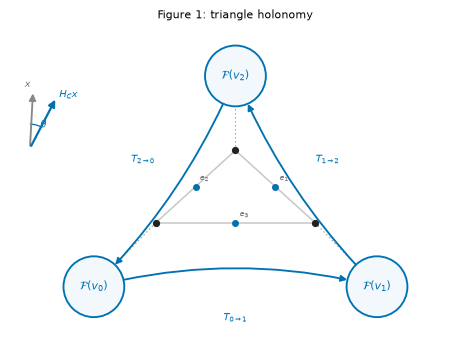

In [1]:
# Figure 1: the audit, drawn. (Schematic; consumed by the papers as fig1.)
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import FancyArrowPatch, Arc, Circle

BLUE = "#0072B2"
fig, ax = plt.subplots(figsize=(6.95, 3.35), constrained_layout=True)
ax.set_axis_off()
ax.set_aspect("equal")
ax.set_xlim(-2.15, 2.15)
ax.set_ylim(-1.10, 1.85)

# Base complex, edge samples, and stalk attachments.
b0, b1, b2 = (np.array(p) for p in
              [(-0.76, -0.02), (0.76, -0.02), (0.00, 0.67)])
stalks = [np.array((-1.35, -0.63)), np.array((1.35, -0.63)),
          np.array((0.00, 1.38))]
for P, Q in [(b0, b1), (b1, b2), (b2, b0)]:
    ax.plot([P[0], Q[0]], [P[1], Q[1]], color="#C7C7C7", lw=1.1, zorder=1)
for P, S in zip([b0, b1, b2], stalks):
    ax.plot([P[0], S[0]], [P[1], S[1]], color="#A8A8A8", lw=0.9,
            ls=(0, (1.2, 2.0)), zorder=0)
    ax.plot(*P, "o", color="#222222", ms=4.2, zorder=5)
for i, (P, Q) in enumerate([(b1, b2), (b2, b0), (b0, b1)], start=1):
    M = (P + Q) / 2
    ax.plot(*M, "o", color=BLUE, ms=4.0, zorder=6)
    ax.text(M[0] + 0.04, M[1] + 0.04, rf"$e_{i}$", color="#777777",
            fontsize=5.8, ha="left", va="bottom")

for i, S in enumerate(stalks):
    ax.add_patch(Circle(S, 0.29, facecolor="#F2F8FC", edgecolor=BLUE,
                        lw=1.35, zorder=2))
    ax.text(*S, rf"$\mathcal{{F}}(v_{i})$", color=BLUE, fontsize=8,
            ha="center", va="center", zorder=3)

# Curved transports between stalks.
for P, Q, rad, lab, pos in [
        (stalks[0], stalks[1], -0.13, r"$T_{0\to 1}$", (0.00, -0.93)),
        (stalks[1], stalks[2], -0.10, r"$T_{1\to 2}$", (0.88, 0.58)),
        (stalks[2], stalks[0], -0.10, r"$T_{2\to 0}$", (-0.88, 0.58))]:
    ax.add_patch(FancyArrowPatch(P, Q, connectionstyle=f"arc3,rad={rad}",
                    arrowstyle="-|>", mutation_scale=9, shrinkA=22, shrinkB=22,
                    lw=1.35, color=BLUE, zorder=4))
    ax.text(*pos, lab, color=BLUE, fontsize=7, ha="center", va="center",
            bbox=dict(boxstyle="round,pad=0.13", fc="white", ec="none", alpha=0.96))

# Classical comparison of a vector x with its returned vector H_C x.
origin = np.array([-1.96, 0.69])
ax.annotate("", xy=origin + np.array([0.03, 0.55]), xytext=origin,
            arrowprops=dict(arrowstyle="-|>", lw=1.35, color="#888888"))
th = 0.48
ax.annotate("", xy=origin + 0.55 * np.array([np.sin(th), np.cos(th)]), xytext=origin,
            arrowprops=dict(arrowstyle="-|>", lw=1.6, color=BLUE))
ax.add_patch(Arc(origin, 0.46, 0.46, theta1=90 - np.degrees(th), theta2=90,
                 lw=0.9, color=BLUE))
ax.text(origin[0] - 0.05, origin[1] + 0.58, r"$x$", fontsize=7, color="#777777")
ax.text(origin[0] + 0.28, origin[1] + 0.48, r"$H_Cx$", fontsize=7, color=BLUE)
ax.text(origin[0] + 0.10, origin[1] + 0.20, r"$\theta$", fontsize=7.5, color=BLUE)

ax.set_title("Figure 1: triangle holonomy", fontsize=8)
plt.show()

In [2]:
import math

import torch

from topobench.nn.backbones.graph.nsd_utils.sheaf_holonomy import (
    cycle_holonomy, rotation_angle, loop_gain, orientation_flip, polar_twist,
)


def rot(theta):
    c, s = math.cos(theta), math.sin(theta)
    return torch.tensor([[c, -s], [s, c]])


r = rot(math.radians(40))
H = cycle_holonomy({(1, 0): r, (2, 1): r, (0, 2): r}, (0, 1, 2))
print(f"twist of three 40-degree transports : {math.degrees(rotation_angle(H)):6.2f} deg (exp. 120)")
print(f"gain |det H| (rotation)             : {loop_gain(H):6.3f}  (exp. 1)")
print(f"flip sign(det H) (rotation)         : {orientation_flip(H):+.0f}      (exp. +1)")
stretch = torch.diag(torch.tensor([2.0, 3.0]))
print(f"polar twist of a pure stretch       : {math.degrees(polar_twist(stretch)):6.2f} deg (exp. 0)")

twist of three 40-degree transports : 120.00 deg (exp. 120)
gain |det H| (rotation)             :  1.000  (exp. 1)
flip sign(det H) (rotation)         : +1      (exp. +1)
polar twist of a pure stretch       :   0.00 deg (exp. 0)


### 3.1&ensp;Instrument verification numerics

Four checks run end-to-end on models trained at the sweep's exact protocol
(`verify_diagnostic.py`; loaded below). *Gauge invariance*: conjugating random $SO(2)$ transports by 1,000
random per-node orthogonal gauges — rotations and reflections — moves twist,
gain and flip by at most $\sim 10^{-15}$. *Singularity rates*: bundle
transports and loop products have $|\det| = 1$ exactly, while trained
diagonal and general loop products are strongly contractive (median
$|\det| \sim 10^{-2}$), which is why their twist must be read with care.
*Stability*: under $\varepsilon$-perturbations the bundle twist is steady,
but near-singular general loop products jitter by $\approx 0.2$ rad at
$\varepsilon = 10^{-4}$ — a quantified caveat we carry into §7. *Exactness of
the intervention*: after the flattening of §5.5, the maximum
$|\mathrm{twist}|$, $|\mathrm{gain} - 1|$ and $\lVert H - I \rVert_F$ over
every audited triangle are exactly $0.0$.

In [3]:
import json
from pathlib import Path

DIAG = Path("diagnostic_checks.json")
diagchecks = json.loads(DIAG.read_text()) if DIAG.exists() else None
if diagchecks is None:
    print("diagnostic_checks.json not found -- run verify_diagnostic.py first.")
else:
    gi = diagchecks["gauge_invariance"]
    print(f"gauge invariance ({gi['n_trials']} random orthogonal gauges): "
          f"max dev twist={gi['max_twist_dev']:.1e} gain={gi['max_gain_dev']:.1e} "
          f"flip={gi['max_flip_dev']:.1e}")
    for fam in ["bundle", "diag", "general"]:
        e, l = diagchecks[f"{fam}_edge_det"], diagchecks[f"{fam}_loop_det"]
        st = diagchecks[f"{fam}_twist_stability"]
        print(f"{fam:8s} |det|: edge median {e['median']:.3g} (frac<1e-3: {e['frac_below_1e3']:.2f}) | "
              f"loop median {l['median']:.3g} | twist std @eps=1e-4: {st['eps_0.0001']:.3g} rad")
    fl = diagchecks["intervention_flatness"]
    print(f"intervention flatness: max|twist|={fl['max_abs_twist']}, "
          f"max|gain-1|={fl['max_abs_gain_minus_1']}, "
          f"max||H-I||_F={fl['max_frobenius_H_minus_I']}")

gauge invariance (1000 random orthogonal gauges): max dev twist=6.7e-16 gain=2.8e-15 flip=0.0e+00
bundle   |det|: edge median 1 (frac<1e-3: 0.00) | loop median 1 | twist std @eps=1e-4: 6.86e-05 rad
diag     |det|: edge median 0.0983 (frac<1e-3: 0.04) | loop median 0.00271 | twist std @eps=1e-4: 0.0278 rad
general  |det|: edge median 0.0869 (frac<1e-3: 0.03) | loop median 0.000544 | twist std @eps=1e-4: 0.195 rad
intervention flatness: max|twist|=0.0, max|gain-1|=0.0, max||H-I||_F=0.0


## 4&ensp;Hypotheses and tests

In DC-SBM generators, triangle counts correlate strongly with degree
statistics. Those are precisely the star-shaped patterns a message-passing
core can access (Chen et al., 2020). The degree shortcut is therefore the
skeptical explanation carried through every test below.

### H1. Recruitment is task-shaped

An $SO(2)$ model should move from
$\bar{\theta}_{\text{init}}$ to
$\bar{\theta}_{\text{final}} \gg \bar{\theta}_{\text{init}}$ for triangle
counting, but remain near initialisation for community detection despite
successful training. **Test:** Figure 2. **Result:** NSP moves from $0.010$ to
$0.388 \pm 0.078$ rad for counting and ends at $0.029 \pm 0.005$ rad for
community detection (Welch $t=14.6$). NSD moves from $0.018$ to
$0.423 \pm 0.075$ rad for counting, but its control arm is bimodal; medians
are $0.399$ versus $0.018$ (Mann–Whitney $p=0.14$). **Verdict:** supported
cleanly for NSP; NSD supports recruitment on counting, but its task contrast
is descriptive rather than claimed.

### H2. Map families respond through their available channels

Diagonal maps should respond through gain and flip rather than twist; general
maps should mix twist with gain ($\text{gain} \neq 1$); bundle maps should
recruit twist at $\text{gain}=1$. **Test:** Figure 3. **Result:** bundle gain
is $1$ identically; diagonal and general gains collapse to $0.042$ and
$0.039$; diagonal frustration under community-detection training falls from
$0.483$ to $0.105$. **Verdict:** supported in all three parts.

### H3. Recruited holonomy pays off in counting skill

More recruited twist should predict lower counting error within and across
map families. **Test:** Figure 4 and the per-split baselines. **Result:**
bundle twist and error are uncorrelated ($r=-0.18$, $p=0.58$). The bundle is
worse than the constant predictor ($\Delta=+0.62 \pm 0.43$); the ridge reaches
$0.110$ MSE while the best sheaf model reaches $0.71$. **Verdict:** not
supported.

### H4. Recruited geometry is load-bearing

Flattening a trained connection should degrade counting and leave the
community-detection control unchanged. **Test:** Figures 5, 7, and 8.
**Result:** at 30 training graphs, counting damage is $+0.48 \pm 0.68$ for NSP
($p=0.052$) and $+0.17 \pm 0.80$ for NSD; neither harm nor equivalence is
established at $\delta=0.20$. Community detection is equivalent within that
margin at $p_{\mathrm{TOST}}<10^{-3}$ for both dynamics. At $N=3000$, damage
reaches $+14$ MSE per seed and persists on 200 fresh test graphs. **Verdict:**
indeterminate at the matched small budget; supported at scale. The control
task behaves as predicted.

### H5. Load-bearing geometry is cycle-functional

If the dependence in H4 reflects triangle-sensitive computation, it should
survive when degree statistics are fixed. **Test:** Figures 6–8. **Result:**
with identifiers, the bundle recruits $0.035 \to 0.501$ rad yet is worse than
the constant predictor ($p_{\mathrm{Holm}}=0.003$). With constant features,
every family is within $|\Delta|\leq0.007$, with twist exactly $0.000$. At
scale, twist climbs to a full radian while performance remains at the constant
predictor; on 200 test graphs $|\Delta|\leq0.04$. **Verdict:** not supported.

## 5&ensp;Design and protocol

| Design | What changes | What it can establish |
|---|---|---|
| Observation | Compare learned readouts with error and task | Association: whether training recruits geometry |
| Intervention | Flatten a **trained** bundle model, leaving its other weights fixed | Whether that trained solution depends on its connection |
| Ablation | Train an ISN flat from scratch, with all weights co-adapted | Whether a flat architecture can solve the task |

The intervention is not the ISN ablation of Hernández Caralt et al. (2026).
Community detection is the smoothing control; triangle counting tests loop
transport. Random regular graphs remove degree statistics.

### 5.1&ensp;Training and evaluation protocol

TopoBench's NSD diffusion (Bodnar et al., 2022) and NSP wave dynamics
(Telyatnikov et al., 2025) use the shared setup in §2.2. The triangle-dense
GraphUniverse probe is distinct from the official 12-regime grid: high
homophily $[0.9,1.0]$, low $[0.0,0.1]$; 30 training/8 test graphs; 100–160
nodes; 5–7 communities; $n=10$ primary seeds and 3 original low-homophily
seeds. Each resamples data and initialisation.

**Protocol.** Adam (lr $10^{-2}$), batch size 8, 60 epochs; the primary grid
is $2 \times 2 \times 3 \times 10 = 120$ runs, and with the 40 intervention
runs and 120 degree-controlled runs (two feature modes) the controls batch
totals 280. Holonomy is measured initially and after training. Plots show
seeds and $\pm1$ standard deviation; exact $p$-values, effects, intervals,
and clustered pooling are reported for $n=10$ cells.

In [4]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

sys.path.insert(0, ".")
from holonomy_experiment import (
    FAMILY_BASE, NUM_CLASSES, REGIMES, SHEAF_TYPES, TASKS, UNIVERSE_KWARGS,
    SheafTaskModel,
)

# Primary data: the 10-seed controls batch (high-homophily regime). The
# original 3-seed sweep (both regimes) remains in holonomy_results.json; its
# low-homophily arm is discussed in the limitations.
records = json.loads(Path("sweep10_results.json").read_text())
rows = []
for r in records:
    row = {k: r[k] for k in
           ("family", "regime", "task", "sheaf_type", "seed",
            "metric", "metric_name")}
    row.update(r["init"])
    row.update({f"final_{k}": v for k, v in r["final"].items()})
    rows.append(row)
df = pd.DataFrame(rows)
df["recruited_twist"] = df["final_twist_mean"] - df["init_twist_mean"]

LOBOTOMY = Path("lobotomy10_results.json")
lob = pd.DataFrame(json.loads(LOBOTOMY.read_text())) if LOBOTOMY.exists() else None
DEGBASE = Path("degree_baseline_results.json")
degbase = pd.DataFrame(json.loads(DEGBASE.read_text())) if DEGBASE.exists() else None
DIAG = Path("diagnostic_checks.json")
diagchecks = json.loads(DIAG.read_text()) if DIAG.exists() else None

TASK_LABEL = {"triangle_counting": "triangle counting",
              "community_detection": "community detection"}
FAM_LABEL = {"nsp": "NSP (wave)", "nsd": "NSD (diffusion)"}
COLORS = {"diag": "#8a94a6", "bundle": "#2f6df6", "general": "#d9642c"}
SEEDS = sorted(df.seed.unique())

print("== Sweep ==")
print(f"{len(df)} runs | families={sorted(df.family.unique())} | "
      f"maps={sorted(df.sheaf_type.unique())} | regimes={sorted(df.regime.unique())} | "
      f"seeds={SEEDS} | intervention runs: {0 if lob is None else len(lob)}")

# --- unified figure system (one semantic meaning per channel) ---------------
# colour = map family; marker/linestyle = dynamics; fill = task
import matplotlib as mpl

FULLW, ONECOL = 6.95, 3.35
FAM_COLORS = {"bundle": "#0072B2", "diag": "#6F6F6F", "general": "#D55E00"}
FAM_NAMES = {"bundle": "SO(2) bundle", "diag": "Diagonal", "general": "General"}
BASE_C = {"degree": "#009E73", "constant": "#111111",
          "initial": "#C7C7C7", "flattened": "#999999"}
DYN = {"nsp": dict(marker="o", linestyle="-"),
       "nsd": dict(marker="s", linestyle="--")}
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans", "Arial", "Helvetica"],
    "mathtext.fontset": "stixsans",
    "font.size": 7.0, "axes.titlesize": 7.5, "axes.labelsize": 7.0,
    "xtick.labelsize": 6.5, "ytick.labelsize": 6.5, "legend.fontsize": 6.3,
    "axes.linewidth": 0.65, "lines.linewidth": 1.25, "lines.markersize": 4.0,
    "errorbar.capsize": 2.5, "xtick.major.width": 0.65,
    "ytick.major.width": 0.65, "xtick.major.size": 3.0,
    "ytick.major.size": 3.0, "axes.spines.top": False,
    "axes.spines.right": False, "axes.grid": False, "legend.frameon": False,
    "figure.dpi": 170, "savefig.bbox": "tight", "savefig.pad_inches": 0.02,
})


def finish_axis(ax):
    ax.grid(axis="y", linewidth=0.45, alpha=0.18)
    ax.tick_params(direction="out")


def ci95_hw(x):
    x = np.asarray(x, dtype=float)
    if len(x) < 2:
        return 0.0
    return stats.t.ppf(.975, len(x) - 1) * x.std(ddof=1) / np.sqrt(len(x))

print()
print("== Model configurations (printed from instantiated encoders) ==")
for fam in ["nsp", "nsd"]:
    m = SheafTaskModel("bundle", "triangle_counting", model_family=fam)
    e = m.encoder
    knobs = {k: getattr(e, k, None) for k in
             ("d", "num_layers", "hidden_dim", "step_size", "sheaf_type")}
    n_params = sum(p.numel() for p in m.parameters())
    print(f"  {FAM_LABEL[fam]:16s}: {knobs} | trainable parameters (incl. head): {n_params:,}")
print(f"  heads: CD = Linear(32 -> {NUM_CLASSES}) per node (cross-entropy); "
      "TC = global mean pool + Linear(32 -> 1) (MSE on standardised log1p)")

print()
print("== Data-generating process (GraphUniverse) ==")
print(f"  universe: {UNIVERSE_KWARGS}")
print(f"  family base (per run): {FAMILY_BASE}")
print(f"  regimes: { {k: v for k, v in REGIMES.items()} }")
print("  per run: 30 train / 8 test graphs; data and initialisation both vary per seed")
print(f"  primary grid (high homophily): 2 dynamics x {len(TASKS)} tasks x "
      f"{len(SHEAF_TYPES)} maps x {len(SEEDS)} seeds = {len(df)} runs")

# Constant-predictor baselines, computed per split (NOT assumed = 1) by
# degree_baselines.py on exactly the sweep's splits; the "const" column of its
# output is the per-split constant-predictor test MSE.
gb = degbase[degbase.setting == "graphuniverse_homophily_hi"]
BASE_GU = {("homophily_hi", int(r.seed)): float(r.const) for r in gb.itertuples()}
rb = degbase[degbase.setting == "regular_n100_r6"]
BASE_REG = {int(r.seed): float(r.const) for r in rb.itertuples()}
print()
print("== Constant-predictor test MSE, computed per split ==")
print("  GraphUniverse hi:", {k[1]: round(v, 3) for k, v in sorted(BASE_GU.items())})
print("  regular graphs  :", {k: round(v, 3) for k, v in sorted(BASE_REG.items())})

== Sweep ==
120 runs | families=['nsd', 'nsp'] | maps=['bundle', 'diag', 'general'] | regimes=['homophily_hi'] | seeds=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9] | intervention runs: 40

== Model configurations (printed from instantiated encoders) ==
  NSP (wave)      : {'d': 2, 'num_layers': 2, 'hidden_dim': 32, 'step_size': 0.5, 'sheaf_type': 'bundle'} | trainable parameters (incl. head): 2,505
  NSD (diffusion) : {'d': 2, 'num_layers': 2, 'hidden_dim': 32, 'step_size': None, 'sheaf_type': 'bundle'} | trainable parameters (incl. head): 2,509
  heads: CD = Linear(32 -> 20) per node (cross-entropy); TC = global mean pool + Linear(32 -> 1) (MSE on standardised log1p)

== Data-generating process (GraphUniverse) ==
  universe: {'K': 20, 'feature_dim': 15, 'center_variance': 0.2, 'cluster_variance': 0.4, 'edge_propensity_variance': 1.0, 'seed': 42}
  family base (per run): {'n_nodes_range': (100, 160), 'n_communities_range': (5, 7), 'avg_degree_range': (5.0, 7.0), 'power_law_exponent_range': (2.0, 2.5

## 6&ensp;Core results

| Claim | Primary evidence | Control |
|---|---|---|
| Geometry is recruited | NSP triangle-counting twist rises forty-fold (§5.1) | Community detection stays near-flat |
| Response depends on map family | Twist, gain and flip separate the families (§5.2) | Gauge and numerical checks (§3.0) |
| Connection becomes load-bearing | Flattening damage grows with data (§5.7) | Small-data result is unresolved (§5.5) |
| Cycle-specific use is not established | Fixed-degree models stay at the constant baseline (§5.6–§5.7) | Twist keeps increasing regardless |

### 6.1&ensp;H1: recruitment is task-shaped

For $n=10$ high-homophily seeds, community accuracy is $0.44$–$0.67$ versus
$0.05$ chance. NSP counting twist rises $0.010\to0.388\pm0.078$ rad, roughly
forty-fold; community training ends at $0.029\pm0.005$ rad (Welch $t=14.6$).
NSD counting similarly rises $0.018\to0.423\pm0.075$ rad. Its community arm
is bimodal: seven of ten seeds near $0.015$ rad and three near $1.6$ rad,
with accuracies $0.44$–$0.47$ versus $0.53$–$0.67$. We therefore report only
a descriptive contrast (medians $0.399$ vs $0.018$; Mann–Whitney $p=0.14$).
H1 is cleanly supported for NSP; Part II examines NSD.

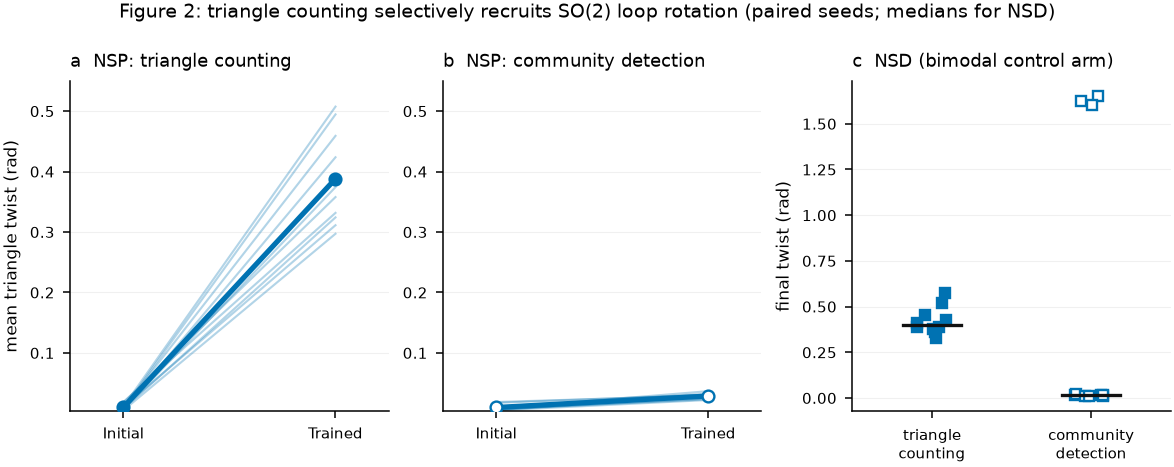

In [5]:
def fig_recruitment(regime="homophily_hi"):
    fig, axes = plt.subplots(1, 3, figsize=(FULLW, 2.5),
                             constrained_layout=True)
    nsp = df[(df.sheaf_type == "bundle") & (df.family == "nsp") &
             (df.regime == regime)]
    for ax, task, filled, ttl in [
            (axes[0], "triangle_counting", True, "a  NSP: triangle counting"),
            (axes[1], "community_detection", False,
             "b  NSP: community detection")]:
        sub = nsp[nsp.task == task]
        for _, r in sub.iterrows():
            ax.plot([0, 1], [r.init_twist_mean, r.final_twist_mean],
                    color=FAM_COLORS["bundle"], alpha=0.30, lw=0.9)
        mfc = FAM_COLORS["bundle"] if filled else "white"
        ax.plot([0, 1], [sub.init_twist_mean.mean(), sub.final_twist_mean.mean()],
                color=FAM_COLORS["bundle"], lw=2.2, marker="o",
                markerfacecolor=mfc, markeredgecolor=FAM_COLORS["bundle"],
                ms=5, zorder=5)
        ax.set_xticks([0, 1])
        ax.set_xticklabels(["Initial", "Trained"])
        ax.set_xlim(-0.25, 1.25)
        ax.set_title(ttl, loc="left")
        finish_axis(ax)
    axes[0].set_ylabel("mean triangle twist (rad)")
    axes[0].set_ylim(axes[1].get_ylim()[0],
                     max(axes[0].get_ylim()[1], 0.55))
    axes[1].set_ylim(axes[0].get_ylim())
    # NSD strip: bimodality shown, not averaged away
    ax = axes[2]
    nsd = df[(df.sheaf_type == "bundle") & (df.family == "nsd") &
             (df.regime == regime)]
    rng = np.random.default_rng(0)
    for i, (task, filled) in enumerate([("triangle_counting", True),
                                        ("community_detection", False)]):
        v = nsd[nsd.task == task].final_twist_mean.values
        x = i + rng.uniform(-0.10, 0.10, len(v))
        mfc = FAM_COLORS["bundle"] if filled else "white"
        ax.plot(x, v, "s", ms=4, markerfacecolor=mfc,
                markeredgecolor=FAM_COLORS["bundle"])
        ax.plot([i - 0.18, i + 0.18], [np.median(v)] * 2,
                color="#111111", lw=1.4)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["triangle\ncounting", "community\ndetection"])
    ax.set_xlim(-0.5, 1.5)
    ax.set_title("c  NSD (bimodal control arm)", loc="left")
    ax.set_ylabel("final twist (rad)")
    finish_axis(ax)
    fig.suptitle("Figure 2: triangle counting selectively recruits SO(2) "
                 "loop rotation (paired seeds; medians for NSD)", y=1.10,
                 fontsize=8)
    return fig


fig_recruitment()
plt.show()

### 6.2&ensp;H2: family capacities and instrument validity

Figure 3 matches Proposition 2.7. Bundle twist changes while
$|\det H|=1$ identically. Diagonal and general gains contract to $0.042$ and
$0.039$. Under community training, diagonal frustration falls from $0.483$
(chance) to $0.105$, consistent with signed-graph balance (Cartwright &
Harary, 1956). H2 is supported in all three parts.

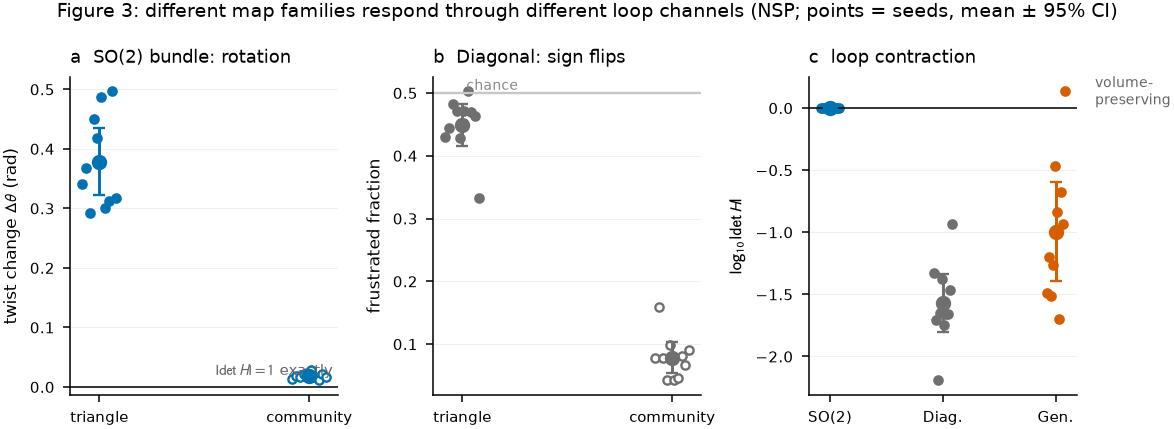

In [6]:
def fig_readouts(family="nsp", regime="homophily_hi"):
    sub = df[(df.family == family) & (df.regime == regime)]
    fig, axes = plt.subplots(1, 3, figsize=(FULLW, 2.3),
                             constrained_layout=True)
    tasks = [("triangle_counting", True), ("community_detection", False)]
    # a: bundle twist change
    ax = axes[0]
    for i, (task, filled) in enumerate(tasks):
        v = sub[(sub.sheaf_type == "bundle") & (sub.task == task)]
        d = (v.final_twist_mean - v.init_twist_mean).values
        mfc = FAM_COLORS["bundle"] if filled else "white"
        ax.plot(np.full(len(d), i) + np.linspace(-.08, .08, len(d)), d, "o",
                ms=3.5, markerfacecolor=mfc,
                markeredgecolor=FAM_COLORS["bundle"])
        ax.errorbar(i, d.mean(), yerr=ci95_hw(d), fmt="o", ms=5.5,
                    color=FAM_COLORS["bundle"], capsize=2.5, zorder=5)
    ax.axhline(0, color="#111111", lw=0.7)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["triangle", "community"])
    ax.set_ylabel(r"twist change $\Delta\theta$ (rad)")
    ax.set_title("a  SO(2) bundle: rotation", loc="left")
    ax.text(0.98, 0.06, r"$|\det H| = 1$ exactly", transform=ax.transAxes,
            ha="right", fontsize=6.2, color="#666666")
    finish_axis(ax)
    # b: diagonal flip
    ax = axes[1]
    for i, (task, filled) in enumerate(tasks):
        v = sub[(sub.sheaf_type == "diag") & (sub.task == task)]
        d = v.final_frustrated_frac.values
        mfc = FAM_COLORS["diag"] if filled else "white"
        ax.plot(np.full(len(d), i) + np.linspace(-.08, .08, len(d)), d, "o",
                ms=3.5, markerfacecolor=mfc, markeredgecolor=FAM_COLORS["diag"])
        ax.errorbar(i, d.mean(), yerr=ci95_hw(d), fmt="o", ms=5.5,
                    color=FAM_COLORS["diag"], capsize=2.5, zorder=5)
    ax.axhline(0.5, color=BASE_C["initial"], lw=1.0)
    ax.text(0.02, 0.505, "chance", fontsize=6.0, color="#888888")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["triangle", "community"])
    ax.set_ylabel("frustrated fraction")
    ax.set_title("b  Diagonal: sign flips", loc="left")
    finish_axis(ax)
    # c: contraction
    ax = axes[2]
    for i, fam in enumerate(["bundle", "diag", "general"]):
        v = np.log10(np.clip(
            sub[(sub.sheaf_type == fam) &
                (sub.task == "triangle_counting")].final_gain_mean.values,
            1e-6, None))
        ax.plot(np.full(len(v), i) + np.linspace(-.08, .08, len(v)), v, "o",
                ms=3.5, color=FAM_COLORS[fam])
        ax.errorbar(i, v.mean(), yerr=ci95_hw(v), fmt="o", ms=5.5,
                    color=FAM_COLORS[fam], capsize=2.5, zorder=5)
    ax.axhline(0, color="#111111", lw=0.7)
    ax.text(2.35, 0.03, "volume-\npreserving", fontsize=6.0, color="#666666")
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(["SO(2)", "Diag.", "Gen."])
    ax.set_ylabel(r"$\log_{10}|\det H|$")
    ax.set_title("c  loop contraction", loc="left")
    finish_axis(ax)
    fig.suptitle("Figure 3: different map families respond through different "
                 "loop channels (NSP; points = seeds, mean ± 95% CI)",
                 y=1.10, fontsize=8)
    return fig


fig_readouts()
plt.show()

### 6.3&ensp;H3: recruited twist does not confer skill

Bundle twist and error are uncorrelated ($r=-0.18$, $p=0.58$). The per-split
constant error averages $0.93$, not the nominal $1$; the bundle is worse by
$\Delta=+0.62\pm0.43$. A ridge on seven degree summaries reaches $0.110$ MSE,
versus $0.71$ for the best sheaf model: a six-fold shortcut advantage,
consistent with 1-WL-accessible star statistics (Chen et al., 2020) and the
identity-sheaf evidence of Hernández Caralt et al. (2026). H3 is not supported.

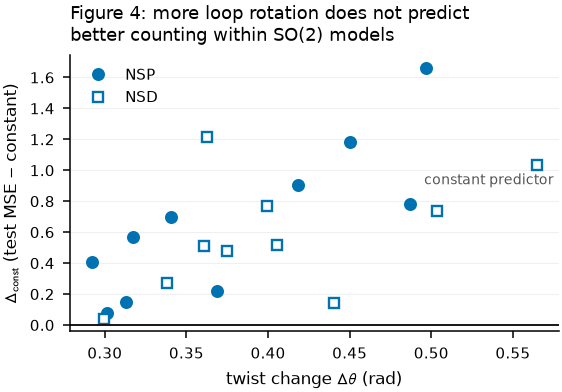

bundle-only correlation, twist change vs raw MSE: r=+0.66, p=0.00 (n=20)


In [7]:
def fig_pays():
    b = df[(df.task == "triangle_counting") & (df.sheaf_type == "bundle")].copy()
    b["d_theta"] = b.final_twist_mean - b.init_twist_mean
    b["d_const"] = b.apply(lambda r: r.metric - BASE_GU[(r.regime, r.seed)],
                           axis=1)
    fig, ax = plt.subplots(figsize=(ONECOL, 2.35), constrained_layout=True)
    for fam in ["nsp", "nsd"]:
        v = b[b.family == fam]
        ax.plot(v.d_theta, v.d_const, DYN[fam]["marker"], ls="none", ms=4.5,
                color=FAM_COLORS["bundle"],
                markerfacecolor=FAM_COLORS["bundle"] if fam == "nsp" else "white",
                label={"nsp": "NSP", "nsd": "NSD"}[fam])
    ax.axhline(0, color=BASE_C["constant"], lw=0.8)
    ax.text(0.99, 0.52, "constant predictor", transform=ax.transAxes,
            ha="right", va="bottom", fontsize=6.0, color="#555555")
    ax.set_xlabel(r"twist change $\Delta\theta$ (rad)")
    ax.set_ylabel(r"$\Delta_{\mathrm{const}}$ (test MSE $-$ constant)")
    ax.set_title("Figure 4: more loop rotation does not predict\n"
                 "better counting within SO(2) models", loc="left", fontsize=7.5)
    ax.legend(loc="upper left")
    finish_axis(ax)
    return fig


fig_pays()
plt.show()

r = stats.pearsonr(
    df[(df.task == "triangle_counting") & (df.sheaf_type == "bundle")]
    .assign(d=lambda x: x.final_twist_mean - x.init_twist_mean).d,
    df[(df.task == "triangle_counting") & (df.sheaf_type == "bundle")].metric)
print(f"bundle-only correlation, twist change vs raw MSE: "
      f"r={r.statistic:+.2f}, p={r.pvalue:.2f} (n={len(df[(df.task=='triangle_counting') & (df.sheaf_type=='bundle')])})")

### 6.4&ensp;H1 across the two dynamics

Wave and diffusion recruit comparable counting twist
($0.378\pm0.078$ and $0.405\pm0.075$ rad). Because NSD's control is unstable,
only recruitment—not the full task contrast—is robust across dynamics.

### 6.5&ensp;H4 intervention: deleting the geometry

**Lemma 5.1.** In the Cayley parametrisation, the restriction map of the zero
parameter vector is the identity: with $A$ the skew-symmetric matrix built
from the parameters, $Q = (I - A)(I + A)^{-1}$, and $A = 0$ gives $Q = I$.
Zeroing every sheaf-learner parameter therefore sets every edge transport to
$I$ — an exactly flat connection — while leaving all other trained weights
untouched. $\square$

Flattening leaves all other trained weights fixed; unlike an ISN ablation
(Hernández Caralt et al., 2026), it asks whether this curved solution depends
on its connection. It shifts triangle-counting
error by $+0.48 \pm 0.68$ under the wave dynamics ($p = 0.052$) and
$+0.17 \pm 0.80$ under diffusion: harmful in direction but unresolved. Neither
passes TOST at the pre-registered $\delta=0.20$ margin (half the largest family
gap). The correct small-data verdict is **indeterminate**. Community detection
is equivalent within that margin at $p_{\mathrm{TOST}}<10^{-3}$ for both
dynamics.

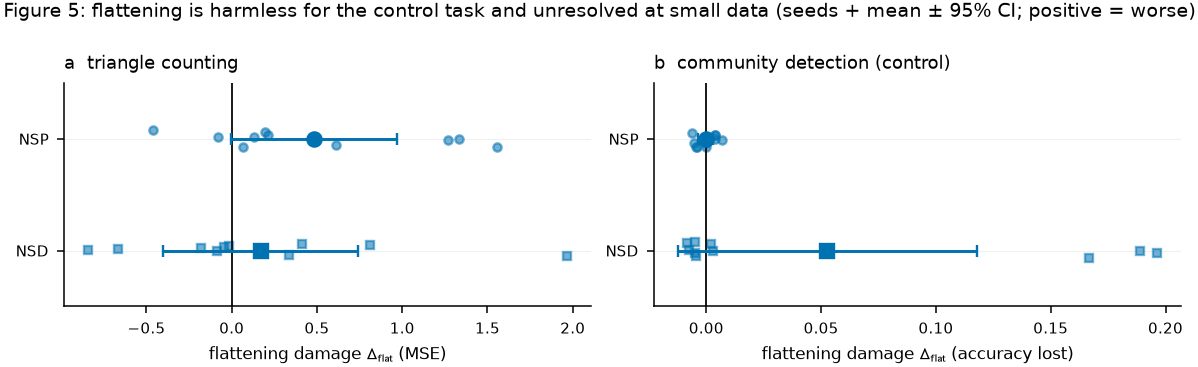

Paired flattening damage (positive = worse):
  nsp triangle_cou: +0.4834 ± 0.6814 (n=10)
  nsd triangle_cou: +0.1693 ± 0.7978 (n=10)
  nsp community_de: -0.0003 ± 0.0047 (n=10)
  nsd community_de: +0.0527 ± 0.0910 (n=10)


In [8]:
if lob is None:
    print("lobotomy10_results.json not found.")
else:
    def fig_lobotomy():
        fig, axes = plt.subplots(1, 2, figsize=(FULLW, 1.9),
                                 constrained_layout=True)
        rng = np.random.default_rng(1)
        for ax, task, ttl, xlab in [
                (axes[0], "triangle_counting",
                 "a  triangle counting",
                 r"flattening damage $\Delta_{\mathrm{flat}}$ (MSE)"),
                (axes[1], "community_detection",
                 "b  community detection (control)",
                 r"flattening damage $\Delta_{\mathrm{flat}}$ (accuracy lost)")]:
            for row, fam in enumerate(["nsp", "nsd"]):
                v = lob[(lob.task == task) & (lob.family == fam)]
                if task == "triangle_counting":
                    d = (v.metric_lobotomy - v.metric).values
                else:  # accuracy: positive = performance worsened
                    d = (v.metric - v.metric_lobotomy).values
                y = np.full(len(d), row) + rng.uniform(-0.08, 0.08, len(d))
                ax.plot(d, y, DYN[fam]["marker"], ls="none", ms=3.5,
                        color=FAM_COLORS["bundle"], alpha=0.55)
                ax.errorbar(d.mean(), row, xerr=ci95_hw(d),
                            fmt=DYN[fam]["marker"], ms=6,
                            color=FAM_COLORS["bundle"], capsize=2.5, zorder=5)
            ax.axvline(0, color=BASE_C["constant"], lw=0.8)
            ax.set_yticks([0, 1]); ax.set_yticklabels(["NSP", "NSD"])
            ax.set_ylim(-0.5, 1.5)
            ax.invert_yaxis()
            ax.set_xlabel(xlab)
            ax.set_title(ttl, loc="left")
            finish_axis(ax)
        fig.suptitle("Figure 5: flattening is harmless for the control task "
                     "and unresolved at small data (seeds + mean ± 95% CI; "
                     "positive = worse)", y=1.14, fontsize=8)
        return fig

    fig_lobotomy()
    plt.show()

    print("Paired flattening damage (positive = worse):")
    for task in ["triangle_counting", "community_detection"]:
        for fam in ["nsp", "nsd"]:
            v = lob[(lob.task == task) & (lob.family == fam)]
            d = (v.metric_lobotomy - v.metric if task == "triangle_counting"
                 else v.metric - v.metric_lobotomy)
            print(f"  {fam} {task[:12]:12s}: {d.mean():+.4f} ± "
                  f"{d.std(ddof=1):.4f} (n={len(d)})")

### 6.6&ensp;H5: counting on regular graphs

$r$-regular graphs fix $(n,r)=(100,6)$, following the motivation—but not the
thousands-of-graphs, several-$(n,r)$ scale—of Chen et al. (2020). Degree
statistics are constant while triangle counts vary (asymptotically
$\mathrm{Poisson}((r-1)^3/6) \approx \mathrm{Poisson}(20.8)$; empirically
$\bar y\approx21$ at $n=100$). We retain 30-train/8-test and test Gaussian
identifiers and constant features. With identifiers, no family extracts wiring
signal. The bundle recruits $0.035\to0.501$ rad yet is worse
than the constant predictor ($p_{\mathrm{Holm}} = 0.003$). With constant
features, every family is at the constant predictor ($|\Delta|\le0.007$) with
twist exactly $0.000$. Random identifiers exceed the anonymous-MPNN ceiling
(Abboud et al., 2021); this is an optimisation and sample-efficiency result,
not a corollary of expressivity theory. H5 is not supported.

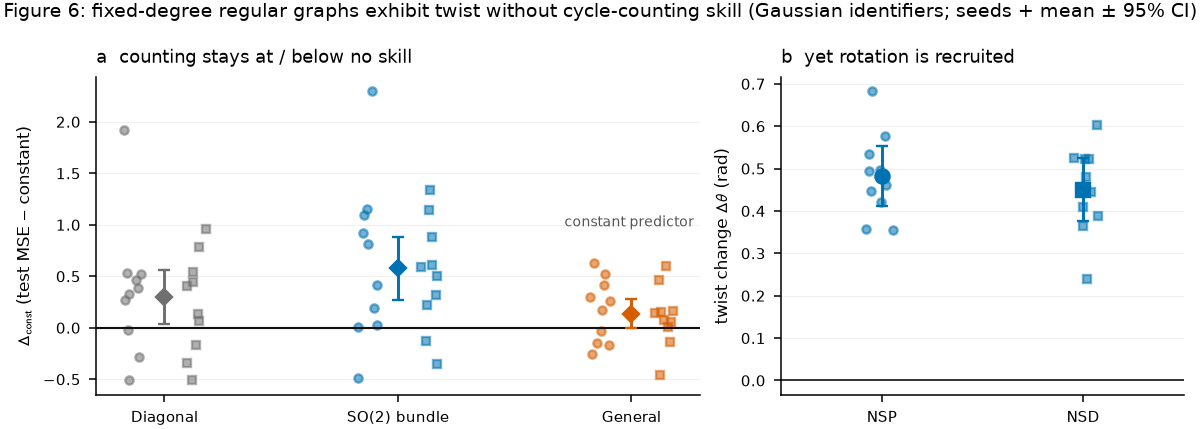

Paired vs each split's constant predictor (n=20/family, clustered):
  diag    : Δ=+0.296 ± 0.561  t=+2.36, p=0.0292, dz=+0.53  | seed-aggregated (n=10): p=0.106
  bundle  : Δ=+0.578 ± 0.658  t=+3.93, p=0.0009, dz=+0.88  | seed-aggregated (n=10): p=0.020
  general : Δ=+0.137 ± 0.294  t=+2.09, p=0.0505, dz=+0.47  | seed-aggregated (n=10): p=0.133
  Holm-adjusted p: {'bundle': 0.0027, 'diag': 0.0584, 'general': 0.0505}
  constant-feature arm: |Δ| max = 0.051 | twist max = 0.0007


In [9]:
REGULAR = Path("regular10_results.json")
reg_all = pd.DataFrame(json.loads(REGULAR.read_text())) if REGULAR.exists() else None
reg = reg_all[reg_all.features == "gaussian"].copy() if reg_all is not None else None
reg_const = reg_all[reg_all.features == "constant"].copy() if reg_all is not None else None

if reg is None:
    print("regular10_results.json not found.")
else:
    reg["d_const"] = reg.apply(lambda r: r.metric - BASE_REG[r.seed], axis=1)
    reg["d_theta"] = reg.final_twist - reg.init_twist

    def fig_regular():
        fig, (axA, axB) = plt.subplots(
            1, 2, figsize=(FULLW, 2.3), width_ratios=[1.5, 1.0],
            constrained_layout=True)
        fams = ["diag", "bundle", "general"]
        rng = np.random.default_rng(2)
        for i, fam in enumerate(fams):
            for dyn in ["nsp", "nsd"]:
                v = reg[(reg.sheaf_type == fam) & (reg.family == dyn)]
                x = np.full(len(v), i) + (-0.13 if dyn == "nsp" else 0.13) \
                    + rng.uniform(-0.05, 0.05, len(v))
                axA.plot(x, v.d_const, DYN[dyn]["marker"], ls="none", ms=3.5,
                         color=FAM_COLORS[fam], alpha=0.55)
            d = reg[reg.sheaf_type == fam].d_const.values
            axA.errorbar(i, d.mean(), yerr=ci95_hw(d), fmt="D", ms=5,
                         color=FAM_COLORS[fam], capsize=2.5, zorder=5)
        axA.axhline(0, color=BASE_C["constant"], lw=0.9)
        axA.text(0.99, 0.53, "constant predictor", transform=axA.transAxes,
                 ha="right", fontsize=6.0, color="#555555")
        axA.set_xticks(range(3))
        axA.set_xticklabels([FAM_NAMES[f] for f in fams])
        axA.set_ylabel(r"$\Delta_{\mathrm{const}}$ (test MSE $-$ constant)")
        axA.set_title("a  counting stays at / below no skill", loc="left")
        finish_axis(axA)
        # panel b: bundle twist change on the same runs
        for dyn in ["nsp", "nsd"]:
            v = reg[(reg.sheaf_type == "bundle") & (reg.family == dyn)]
            x = (0 if dyn == "nsp" else 1) + rng.uniform(-0.08, 0.08, len(v))
            axB.plot(x, v.d_theta, DYN[dyn]["marker"], ls="none", ms=3.5,
                     color=FAM_COLORS["bundle"], alpha=0.55)
            axB.errorbar(0 if dyn == "nsp" else 1, v.d_theta.mean(),
                         yerr=ci95_hw(v.d_theta.values),
                         fmt=DYN[dyn]["marker"], ms=6,
                         color=FAM_COLORS["bundle"], capsize=2.5, zorder=5)
        axB.axhline(0, color="#111111", lw=0.7)
        axB.set_xticks([0, 1]); axB.set_xticklabels(["NSP", "NSD"])
        axB.set_xlim(-0.5, 1.5)
        axB.set_ylabel(r"twist change $\Delta\theta$ (rad)")
        axB.set_title("b  yet rotation is recruited", loc="left")
        finish_axis(axB)
        fig.suptitle("Figure 6: fixed-degree regular graphs exhibit twist "
                     "without cycle-counting skill (Gaussian identifiers; "
                     "seeds + mean ± 95% CI)", y=1.10, fontsize=8)
        return fig

    fig_regular()
    plt.show()

    print("Paired vs each split's constant predictor (n=20/family, clustered):")
    ps = {}
    for m in ["diag", "bundle", "general"]:
        d = reg[reg.sheaf_type == m]["d_const"]
        tt = stats.ttest_1samp(d, 0)
        agg = reg[reg.sheaf_type == m].groupby("seed")["d_const"].mean()
        t3 = stats.ttest_1samp(agg, 0)
        ps[m] = tt.pvalue
        print(f"  {m:8s}: Δ={d.mean():+.3f} ± {d.std(ddof=1):.3f}  "
              f"t={tt.statistic:+.2f}, p={tt.pvalue:.4f}, "
              f"dz={d.mean()/d.std(ddof=1):+.2f}  "
              f"| seed-aggregated (n={len(agg)}): p={t3.pvalue:.3f}")
    order = sorted(ps, key=ps.get)
    holm = {m: min(ps[m] * (3 - i), 1.0) for i, m in enumerate(order)}
    print("  Holm-adjusted p:", {m: round(v, 4) for m, v in holm.items()})
    if reg_const is not None:
        rc = reg_const.copy()
        rc["d_const"] = rc.apply(lambda r: r.metric - BASE_REG[r.seed], axis=1)
        print("  constant-feature arm: |Δ| max =",
              round(rc.d_const.abs().max(), 4),
              "| twist max =", round(rc.final_twist.max(), 4))

### 6.7&ensp;H4 and H5 at scale: the reversal

We trained the diagonal and bundle models at
$N_{\mathrm{train}} \in \{30, 100, 300, 1000, 3000\}$ on both datasets,
with fixed test splits (3 seeds), bundle flattening, and refitted baselines.
Pre-declared outcomes were: (1) improvement plus flattening damage; (2)
improvement without damage; (3) twist growth without improvement; (4) degree
baseline parity. GraphUniverse gives (1). At $N=3000$, both families beat the constant on every
seed (bundle $1.11 \to 0.52$; diagonal $0.70 \to 0.29$) — and flattening,
indeterminate at $N=30$, reaches $+14$ MSE per seed at $N=3000$. Yet the
ridge remains $\approx0.075$ at every $N$. Regular graphs give (3): twist
reaches a full radian while performance stays at the constant predictor.
Data makes geometry necessary, not cycle-functional.

Flattened errors include co-adaptation in a coupled system. The regular null
shows that the load-bearing computation is not wiring.

## 7&ensp;Discussion and verdict

Optimisation recruits geometry selectively, eventually depends on it, and
routes the cheapest available signal through it—here, degree statistics.
Recruitment, dependence, and cycle function are distinct; only the first two
are demonstrated. This mechanism complements the identity-sheaf result of
Hernández Caralt et al. (2026). Mechanistic claims should measure geometry,
delete it, and test degree-controlled graphs. **Verdict:** recruited, then
required, never cycle-functional.

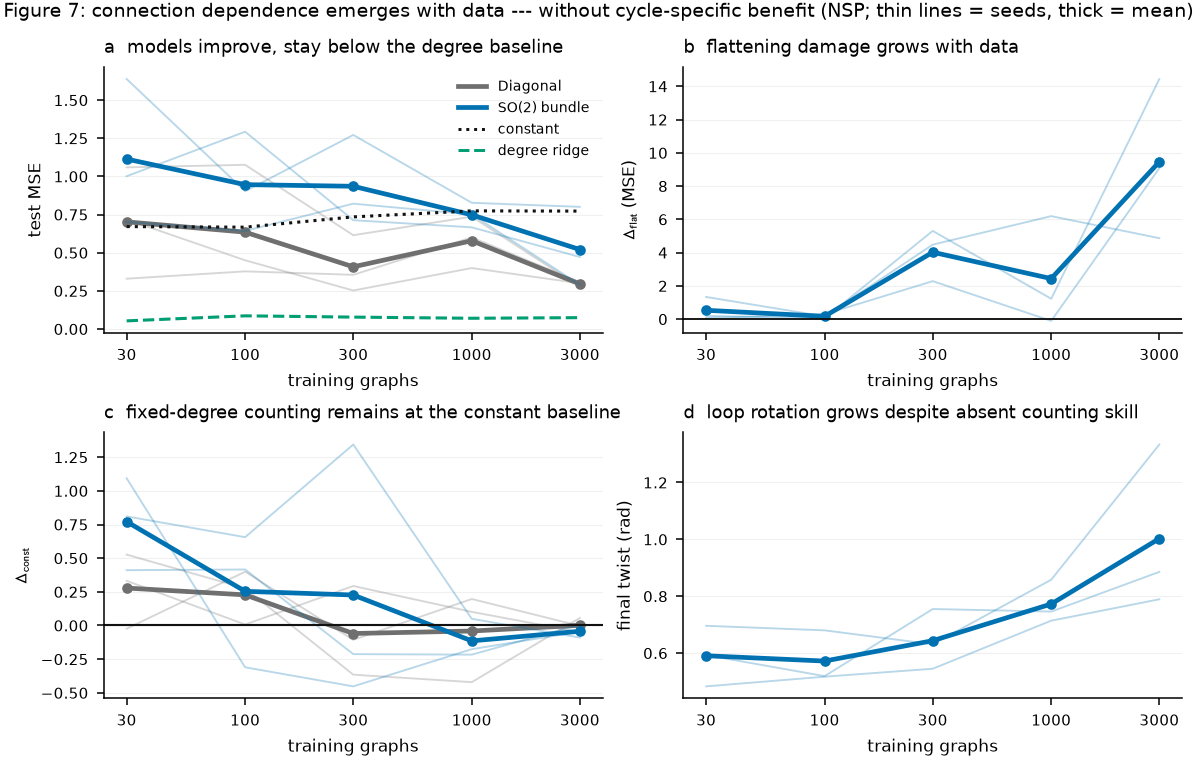

GU flattening damage per seed by N:
  N=  30: [1.33 0.07 0.19]  paired t=+1.32 p=0.318
  N= 100: [0.16 0.29 0.05]  paired t=+2.36 p=0.142
  N= 300: [4.48 2.28 5.3 ]  paired t=+4.46 p=0.047
  N=1000: [ 6.19 -0.11  1.22]  paired t=+1.27 p=0.332
  N=3000: [ 4.87  9.08 14.44]  paired t=+3.42 p=0.076


In [10]:
sc = pd.DataFrame(json.loads(Path("scaling_results.json").read_text()))
scb = pd.DataFrame(json.loads(Path("scaling_baseline_results.json").read_text()))
SIZES = [30, 100, 300, 1000, 3000]


def _seed_curves(ax, sub, ycol, color, lw_mean=2.0):
    for _, g in sub.groupby("seed"):
        g = g.sort_values("n_train")
        ax.plot(g.n_train, g[ycol], color=color, alpha=0.28, lw=0.8)
    m = sub.groupby("n_train")[ycol].mean()
    ax.plot(m.index, m.values, color=color, lw=lw_mean, marker="o", ms=3.5)


def fig_scaling():
    fig, axes = plt.subplots(2, 2, figsize=(FULLW, 4.3),
                             constrained_layout=True)
    # a: GU performance
    ax = axes[0, 0]
    gu = sc[sc.dataset == "graphuniverse"]
    for fam in ["diag", "bundle"]:
        _seed_curves(ax, gu[gu.sheaf_type == fam], "metric", FAM_COLORS[fam])
    bl = scb[scb.dataset == "graphuniverse"].groupby("n_train")[
        ["const", "deg_moments"]].mean()
    ax.plot(bl.index, bl["const"], ":", color=BASE_C["constant"], lw=1.3,
            label="constant")
    ax.plot(bl.index, bl["deg_moments"], "--", color=BASE_C["degree"], lw=1.3,
            label="degree ridge")
    ax.set_ylabel("test MSE")
    ax.set_title("a  models improve, stay below the degree baseline",
                 loc="left")
    ax.legend(loc="upper right")
    # b: GU flattening damage
    ax = axes[0, 1]
    b = gu[gu.sheaf_type == "bundle"].copy()
    b["d_flat"] = b.metric_lobotomy - b.metric
    _seed_curves(ax, b, "d_flat", FAM_COLORS["bundle"])
    ax.axhline(0, color=BASE_C["constant"], lw=0.8)
    ax.set_ylabel(r"$\Delta_{\mathrm{flat}}$ (MSE)")
    ax.set_title("b  flattening damage grows with data", loc="left")
    # c: regular Δ_const
    ax = axes[1, 0]
    rg = sc[sc.dataset == "regular"].copy()
    rg["d_const"] = rg.apply(
        lambda r: r.metric
        - scb[(scb.dataset == "regular") & (scb.n_train == r.n_train) &
              (scb.seed == r.seed)].const.iloc[0], axis=1)
    for fam in ["diag", "bundle"]:
        _seed_curves(ax, rg[rg.sheaf_type == fam], "d_const", FAM_COLORS[fam])
    ax.axhline(0, color=BASE_C["constant"], lw=0.9)
    ax.set_ylabel(r"$\Delta_{\mathrm{const}}$")
    ax.set_title("c  fixed-degree counting remains at the constant baseline",
                 loc="left")
    # d: regular twist
    ax = axes[1, 1]
    rb = rg[rg.sheaf_type == "bundle"]
    _seed_curves(ax, rb, "final_twist", FAM_COLORS["bundle"])
    ax.set_ylabel("final twist (rad)")
    ax.set_title("d  loop rotation grows despite absent counting skill",
                 loc="left")
    for ax in axes.ravel():
        ax.set_xscale("log")
        ax.set_xticks(SIZES)
        ax.set_xticklabels([str(n) for n in SIZES])
        ax.minorticks_off()
        ax.set_xlabel("training graphs")
        finish_axis(ax)
    from matplotlib.lines import Line2D
    axes[0, 0].legend(handles=[
        Line2D([], [], color=FAM_COLORS["diag"], lw=2, label="Diagonal"),
        Line2D([], [], color=FAM_COLORS["bundle"], lw=2, label="SO(2) bundle"),
        Line2D([], [], color=BASE_C["constant"], ls=":", label="constant"),
        Line2D([], [], color=BASE_C["degree"], ls="--", label="degree ridge"),
    ], loc="upper right", fontsize=6.0)
    fig.suptitle("Figure 7: connection dependence emerges with data --- "
                 "without cycle-specific benefit (NSP; thin lines = seeds, "
                 "thick = mean)", y=1.04, fontsize=8)
    return fig


fig_scaling()
plt.show()

print("GU flattening damage per seed by N:")
for n in SIZES:
    bb = sc[(sc.dataset == "graphuniverse") & (sc.sheaf_type == "bundle") &
            (sc.n_train == n)].sort_values("seed")
    d = (bb.metric_lobotomy - bb.metric)
    tt = stats.ttest_rel(bb.metric_lobotomy, bb.metric)
    print(f"  N={n:4d}: {np.round(d.values,2)}  paired t={tt.statistic:+.2f} "
          f"p={tt.pvalue:.3f}")

## Part II - Further analysis

## 8&ensp;Instrument verification and diagnostic detail

The numerical checks in §3.1 appear early because their code must precede the
analysis cells. They establish gauge invariance to $\sim 10^{-15}$,
bundle $|\det|=1$, near-singular general-map jitter of $\approx 0.2$ rad at
$\varepsilon=10^{-4}$, and exact flattening at $0.0$.

## 9&ensp;NSD bimodality and degree baselines

Figure 2c contains the NSD deep-dive: seven of ten community seeds lie near
$0.015$ rad; three lie near $1.6$ rad with accuracies $0.44$–$0.47$ rather
than $0.53$–$0.67$. Hence medians $0.399$ versus $0.018$ and Mann–Whitney
$p=0.14$ remain descriptive. Degree-baseline construction and per-split
constants are printed above; the seven-statistic ridge reaches $0.110$ MSE
against the best sheaf model's $0.71$.

## 10&ensp;Reproduction on 200 graphs

A fair objection: the curves above rest on eight fixed test graphs. We
therefore re-evaluated the pivotal models — GraphUniverse at
$N \in \{300, 3000\}$ and regular graphs at $N = 3000$ — on freshly
generated 200-graph test families. Checkpoints were not saved, so each
configuration was retrained under its identical seed, protocol and training
split; this reproduces the original 8-graph metric closely (median
difference $0$; 72% of runs within $0.01$; a few long $N = 3000$ runs drift
by up to $0.26$, since `scatter_add` in the sheaf Laplacian is not
bit-reproducible over 60 epochs).

Every pre-registered sign survives the larger test (Figure 8): flattening
remains catastrophic on GraphUniverse; both families still beat the constant
at $N = 3000$ on every seed; the ridge baseline still beats them; and twist
still grows past a radian. Better, the one place the small test had
misled us, it had misled us *against* our own conclusion: on eight graphs
the regular-graph models appeared to sit noisily above the constant
predictor, whereas on 200 they sit exactly on it ($|\Delta| \le 0.04$). The
larger test removes an artefact and leaves the dissociation cleaner than we
had claimed.

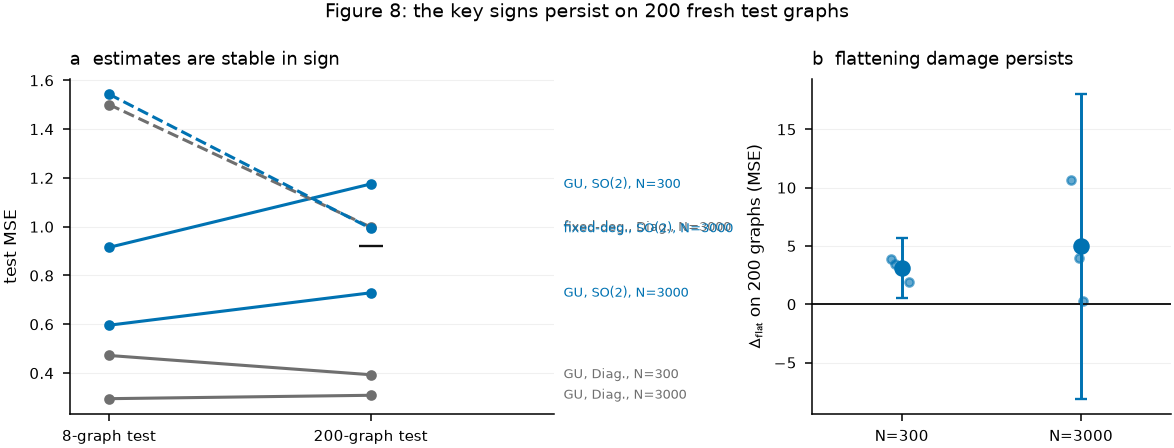

Reproduction checksum (200-graph run's 8-graph metric vs original):
  median 0.0000 | max 0.260 | frac<0.01 0.72 (scatter_add non-reproducibility)


In [11]:
bt = pd.DataFrame(json.loads(Path("bigtest_results.json").read_text()))


def fig_bigtest():
    fig, (axA, axB) = plt.subplots(
        1, 2, figsize=(FULLW, 2.4), width_ratios=[1.35, 1.0],
        constrained_layout=True)
    cfgs = [("graphuniverse", "diag", 300), ("graphuniverse", "bundle", 300),
            ("graphuniverse", "diag", 3000), ("graphuniverse", "bundle", 3000),
            ("regular", "diag", 3000), ("regular", "bundle", 3000)]
    for d_, m_, n_ in cfgs:
        g = bt[(bt.dataset == d_) & (bt.sheaf_type == m_) & (bt.n_train == n_)]
        y8, y200 = g.metric8_reproduced.mean(), g.metric_big.mean()
        ls = "-" if d_ == "graphuniverse" else "--"
        axA.plot([0, 1], [y8, y200], ls=ls, marker="o", ms=3.5,
                 color=FAM_COLORS[m_], lw=1.3)
        lab = f"{'GU' if d_ == 'graphuniverse' else 'fixed-deg.'}, " \
              f"{'SO(2)' if m_ == 'bundle' else 'Diag.'}, N={n_}"
        axA.annotate(lab, (1.02, y200), fontsize=5.6,
                     color=FAM_COLORS[m_], va="center",
                     xycoords=("axes fraction", "data"))
    c200 = bt.groupby("dataset").const_big.mean()
    axA.plot([1], [c200["graphuniverse"]], marker="_", ms=10,
             color=BASE_C["constant"])
    axA.set_xticks([0, 1])
    axA.set_xticklabels(["8-graph test", "200-graph test"])
    axA.set_xlim(-0.15, 1.7)
    axA.set_ylabel("test MSE")
    axA.set_title("a  estimates are stable in sign", loc="left")
    finish_axis(axA)
    rng = np.random.default_rng(3)
    for i, n_ in enumerate([300, 3000]):
        g = bt[(bt.dataset == "graphuniverse") & (bt.sheaf_type == "bundle") &
               (bt.n_train == n_)]
        d = (g.metric_big_lobotomy - g.metric_big).values
        x = np.full(len(d), i) + rng.uniform(-0.07, 0.07, len(d))
        axB.plot(x, d, "o", ms=3.5, color=FAM_COLORS["bundle"], alpha=0.6)
        axB.errorbar(i, d.mean(), yerr=ci95_hw(d), fmt="o", ms=6,
                     color=FAM_COLORS["bundle"], capsize=2.5, zorder=5)
    axB.axhline(0, color=BASE_C["constant"], lw=0.8)
    axB.set_xticks([0, 1]); axB.set_xticklabels(["N=300", "N=3000"])
    axB.set_xlim(-0.5, 1.5)
    axB.set_ylabel(r"$\Delta_{\mathrm{flat}}$ on 200 graphs (MSE)")
    axB.set_title("b  flattening damage persists", loc="left")
    finish_axis(axB)
    fig.suptitle("Figure 8: the key signs persist on 200 fresh test graphs",
                 y=1.10, fontsize=8)
    return fig


fig_bigtest()
plt.show()

print("Reproduction checksum (200-graph run's 8-graph metric vs original):")
diffs = []
for r in bt.itertuples():
    o = sc[(sc.dataset == r.dataset) & (sc.sheaf_type == r.sheaf_type) &
           (sc.n_train == r.n_train) & (sc.seed == r.seed)].metric
    if len(o):
        diffs.append(abs(r.metric8_reproduced - o.iloc[0]))
diffs = np.array(diffs)
print(f"  median {np.median(diffs):.4f} | max {diffs.max():.3f} | "
      f"frac<0.01 {(diffs < 0.01).mean():.2f} "
      f"(scatter_add non-reproducibility)")

## 11&ensp;Statistical summary

Table 1 collects every test in the study — effect sizes, confidence
intervals, Holm corrections and TOST equivalence bounds — with clustered
pooling flagged wherever the two dynamics share seeds. Sample sizes are
moderate by design ($n = 10$ per cell in the controls; $n = 3$ in the
scaling grid), and we lean on the order-of-magnitude effects rather than
significance thresholds.

In [12]:
def ci95(d):
    se = d.std(ddof=1) / np.sqrt(len(d))
    tc = stats.t.ppf(.975, len(d) - 1)
    return f"[{d.mean()-tc*se:+.3f}, {d.mean()+tc*se:+.3f}]"


tests = []
for fam in ["nsp", "nsd"]:
    sub = df[(df.sheaf_type == "bundle") & (df.family == fam) &
             (df.regime == "homophily_hi")]
    a = sub[sub.task == "triangle_counting"]["final_twist_mean"]
    b = sub[sub.task == "community_detection"]["final_twist_mean"]
    tt = stats.ttest_ind(a, b, equal_var=False)
    sp = np.sqrt((a.var(ddof=1) + b.var(ddof=1)) / 2)
    dof = len(a) + len(b) - 2
    g = (a.mean() - b.mean()) / sp * (1 - 3 / (4 * dof - 1))  # Hedges small-sample correction
    tests.append([f"H3.2 recruitment ({fam}): final twist, TC vs CD", "Welch t",
                  f"{tt.statistic:.2f}", f"{tt.pvalue:.2g}", f"g={g:.1f}", "",
                  f"{a.mean():.3f} vs {b.mean():.3f} rad (n={len(a)}/group)"])

tri = df[df.task == "triangle_counting"]
b_ = tri[tri.sheaf_type == "bundle"]
prb = stats.pearsonr(b_["recruited_twist"], b_["metric"])
tests.append(["H3.4 payoff: recruited twist vs error (bundle only)", "Pearson r",
              f"{prb.statistic:+.2f}", f"{prb.pvalue:.2f}", "", "", "n=12"])
pr = stats.pearsonr(tri["recruited_twist"], tri["metric"])
tests.append(["H3.4 payoff: pooled (DESCRIPTIVE — clustered seeds/families)",
              "Pearson r", f"{pr.statistic:+.2f}", "—", "", "",
              f"n={len(tri)}; not treated as inferential"])

hi = tri[tri.regime == "homophily_hi"].copy()
hi["delta_base"] = hi.apply(lambda r: r.metric - BASE_GU[(r.regime, r.seed)], axis=1)
tt = stats.ttest_ind(hi[hi.sheaf_type == "diag"]["metric"],
                     hi[hi.sheaf_type == "bundle"]["metric"], equal_var=False)
tests.append(["H3.4 skill: diagonal vs bundle error (GU hi)", "Welch t",
              f"{tt.statistic:.2f}", f"{tt.pvalue:.3f}", "", "",
              "degrees of failure, not skill (see baseline rows)"])
for m in ["diag", "general", "bundle"]:
    d = hi[hi.sheaf_type == m]["delta_base"]
    t1 = stats.ttest_1samp(d, 0)
    tests.append([f"H3.4 GU hi: {m} vs ACTUAL const baseline", "paired t on Δ",
                  f"{t1.statistic:+.2f}", f"{t1.pvalue:.3f}",
                  f"dz={d.mean()/d.std(ddof=1):+.2f}", ci95(d),
                  f"Δ={d.mean():+.3f}±{d.std(ddof=1):.3f} (n=6, clustered)"])

if lob is not None:
    for task in ["triangle_counting", "community_detection"]:
        for fam in ["nsp", "nsd"]:
            sf = lob[(lob.task == task) & (lob.family == fam)]
            d = sf["metric_lobotomy"] - sf["metric"]
            tt = stats.ttest_rel(sf["metric_lobotomy"], sf["metric"])
            tests.append([f"H3.5 intervention {fam}: {task}", "paired t on Δ",
                          f"{tt.statistic:+.2f}", f"{tt.pvalue:.3f}",
                          f"dz={d.mean()/d.std(ddof=1):+.2f}", ci95(d),
                          f"Δ={d.mean():+.3f}±{d.std(ddof=1):.3f} (n={len(d)})"])
        sp_ = lob[lob.task == task]
        d = sp_["metric_lobotomy"] - sp_["metric"]
        tt = stats.ttest_rel(sp_["metric_lobotomy"], sp_["metric"])
        tests.append([f"H3.5 intervention POOLED: {task}", "paired t on Δ",
                      f"{tt.statistic:+.2f}", f"{tt.pvalue:.3f}",
                      f"dz={d.mean()/d.std(ddof=1):+.2f}", ci95(d),
                      f"Δ={d.mean():+.3f}±{d.std(ddof=1):.3f} (n=6, CLUSTERED: 3 seeds x 2 dynamics)"])

if reg is not None:
    reg2 = reg.copy()
    reg2["delta_base"] = reg2.apply(lambda r: r.metric - BASE_REG[r.seed], axis=1)
    ps = {}
    for m in ["diag", "bundle", "general"]:
        d = reg2[reg2.sheaf_type == m]["delta_base"]
        t1 = stats.ttest_1samp(d, 0)
        ps[m] = (t1, d)
    order = sorted(ps, key=lambda m: ps[m][0].pvalue)
    holm = {m: min(ps[m][0].pvalue * (3 - i), 1.0) for i, m in enumerate(order)}
    for m in ["diag", "bundle", "general"]:
        t1, d = ps[m]
        tests.append([f"Sec5.6 regular: {m} vs ACTUAL const baseline", "paired t on Δ",
                      f"{t1.statistic:+.2f}",
                      f"{t1.pvalue:.4f} (Holm {holm[m]:.4f})",
                      f"dz={d.mean()/d.std(ddof=1):+.2f}", ci95(d),
                      f"Δ={d.mean():+.3f}±{d.std(ddof=1):.3f} (n=6, clustered)"])

# Robust recruitment tests (NSD's CD arm is bimodal; means are invalid there).
for fam in ["nsp", "nsd"]:
    sub = df[(df.sheaf_type == "bundle") & (df.family == fam)]
    a = sub[sub.task == "triangle_counting"]["final_twist_mean"]
    b = sub[sub.task == "community_detection"]["final_twist_mean"]
    u = stats.mannwhitneyu(a, b, alternative="two-sided")
    tests.append([f"H3.2 recruitment ({fam}), robust", "Mann-Whitney U",
                  f"{u.statistic:.0f}", f"{u.pvalue:.2g}", "", "",
                  f"medians {a.median():.3f} vs {b.median():.3f} rad"])

# TOST equivalence tests against the pre-registered margin delta = 0.20.
DELTA = 0.20
def tost_p(d, delta=DELTA):
    n = len(d); se = d.std(ddof=1) / np.sqrt(n)
    p_lo = 1 - stats.t.cdf((d.mean() + delta) / se, n - 1)
    p_hi = stats.t.cdf((d.mean() - delta) / se, n - 1)
    return max(p_lo, p_hi)

if lob is not None:
    for task in ["triangle_counting", "community_detection"]:
        for fam in ["nsp", "nsd"]:
            sf = lob[(lob.task == task) & (lob.family == fam)]
            d = sf["metric_lobotomy"] - sf["metric"]
            tests.append([f"H3.5 TOST equivalence (|Δ|<{DELTA}) {fam}: {task}",
                          "TOST", "", f"{tost_p(d):.3f}", "", "",
                          "equivalent" if tost_p(d) < 0.05 else "NOT established"])

# Measured degree shortcut (ridge regressors on the same splits).
if degbase is not None:
    gb = degbase[degbase.setting == "graphuniverse_homophily_hi"]
    tests.append(["Sec5.3 measured shortcut: ridge on degree moments (GU hi)",
                  "test MSE", f"{gb['deg_moments'].mean():.3f}", "—", "", "",
                  f"vs const {gb['const'].mean():.3f}; best neural "
                  f"{hi[hi.sheaf_type=='diag']['metric'].mean():.3f} (n=10 splits)"])

# Constant-feature regular-graph arm: all families sit on the baseline.
if reg_const is not None:
    rc = reg_const.copy()
    rc["delta_base"] = rc.apply(lambda r: r.metric - BASE_REG[r.seed], axis=1)
    for m in ["diag", "bundle", "general"]:
        d = rc[rc.sheaf_type == m]["delta_base"]
        t1 = stats.ttest_1samp(d, 0)
        tests.append([f"Sec5.6 regular (CONSTANT features): {m} vs baseline",
                      "paired t on Δ", f"{t1.statistic:+.2f}", f"{t1.pvalue:.3f}",
                      f"dz={d.mean()/d.std(ddof=1):+.2f}", ci95(d),
                      f"Δ={d.mean():+.4f}±{d.std(ddof=1):.4f} (n={len(d)})"])

summary = pd.DataFrame(
    tests,
    columns=["comparison", "test", "statistic", "p", "effect", "95% CI", "note"])
pd.set_option("display.max_colwidth", 90)
summary

,comparison,test,statistic,p,effect,95% CI,note
0,"H3.2 recruitment (nsp): final twist, TC vs CD",Welch t,14.59,1.3e-07,g=6.2,,0.388 vs 0.029 rad (n=10/group)
1,"H3.2 recruitment (nsd): final twist, TC vs CD",Welch t,-0.30,0.77,g=-0.1,,0.423 vs 0.498 rad (n=10/group)
2,H3.4 payoff: recruited twist vs error (bundle only),Pearson r,+0.66,0.00,,,n=12
3,H3.4 payoff: pooled (DESCRIPTIVE — clustered seeds/families),Pearson r,+0.62,—,,,n=60; not treated as inferential
4,H3.4 skill: diagonal vs bundle error (GU hi),Welch t,-4.70,0.000,,,"degrees of failure, not skill (see baseline rows)"
5,H3.4 GU hi: diag vs ACTUAL const baseline,paired t on Δ,-2.40,0.027,dz=-0.54,"[-0.401, -0.028]","Δ=-0.215±0.399 (n=6, clustered)"
6,H3.4 GU hi: general vs ACTUAL const baseline,paired t on Δ,-1.38,0.183,dz=-0.31,"[-0.271, +0.055]","Δ=-0.108±0.348 (n=6, clustered)"
7,H3.4 GU hi: bundle vs ACTUAL const baseline,paired t on Δ,+6.42,0.000,dz=+1.44,"[+0.416, +0.819]","Δ=+0.618±0.430 (n=6, clustered)"
8,H3.5 intervention nsp: triangle_counting,paired t on Δ,+2.24,0.052,dz=+0.71,"[-0.004, +0.971]",Δ=+0.483±0.681 (n=10)
9,H3.5 intervention nsd: triangle_counting,paired t on Δ,+0.67,0.519,dz=+0.21,"[-0.401, +0.740]",Δ=+0.169±0.798 (n=10)


## 12&ensp;Limitations

*Statistical.* Ten seeds per cell power the primary contrasts; the scaling
grid uses three. The counting-task intervention at small $N$ remains
indeterminate at the pre-registered margin — that is a statement about
resolution, reported as such — and pooled rows share seeds across dynamics,
which we flag as clustered wherever they appear.

*Architectural.* The audited models are small ($d = 2$, two layers, 32
hidden units), and NSD's bimodal control arm limits its recruitment claim to
a description. Whether larger stalks recruit richer holonomy than a single
rotation plane is open. The audit reads the final layer; it does not track
how loop products evolve across layers. The flattening intervention is exact
only for the bundle family (Lemma 5.1); the fixed-epoch protocol means large-$N$ models
also see proportionally more gradient steps.

*Interpretive.* The polar twist of near-singular general-map loop products is
numerically fragile ($\approx 0.2$ rad jitter at $10^{-4}$ perturbations;
§3.0), so diagonal and general twist values are indicative only. Gaussian
identifiers formally exceed the anonymous-MPNN ceiling (Abboud et al.,
2021), so the regular-graph failures are facts about training at this
budget, not corollaries of expressivity theory. The probe grid is synthetic,
deliberately triangle-dense, and distinct from the official challenge grid;
the triangle-sparse low-homophily arm (3 seeds) shows correspondingly weaker
recruitment. Triangles are the shortest cycles; longer ones await. The matched
small-budget comparisons use only 30 training graphs.

## 13&ensp;Outlook

Concrete next steps are to audit every layer rather than only the last;
extend the readouts beyond triangles to longer cycle bases; repeat the
intervention with larger stalk dimensions and budgets matched by optimiser
steps; and build degree-conditioned graph families in which triangle count
varies while the degree sequence is fixed. Saving checkpoints would separate
test-set variance from retraining drift. Interventions for diagonal and
general maps would test whether their gain and flip channels become
load-bearing.

**Reproducibility.** Metric: `sheaf_holonomy.py` (18 unit tests, incl. gauge
invariance); capture: `holonomy_capture.py` (8 tests); verification:
`verify_diagnostic.py` → `diagnostic_checks.json`; sweep:
`holonomy_experiment.py`; intervention: `holonomy_lobotomy.py`;
degree-controlled follow-up: `holonomy_regular.py` (both feature modes);
measured baselines: `degree_baselines.py` → `degree_baseline_results.json`;
scaling: `scaling_experiment.py` + `scaling_baselines.py` →
`scaling_results.json` (60 runs); big-test verification:
`bigtest_eval.py` → `bigtest_results.json` (18 runs on 200-graph test sets);
data: `sweep10_results.json` (120), `lobotomy10_results.json` (40),
`regular10_results.json` (120), plus the original 3-seed sweep
(`holonomy_results.json`, both regimes). All experiments run on CPU in
minutes to hours; the batches parallelise across containers.

## References

- R. Abboud, İ. İ. Ceylan, M. Grohe, T. Lukasiewicz. The Surprising Power of
  Graph Neural Networks with Random Node Initialization. *IJCAI*, 2021.
- F. Barbero, C. Bodnar, H. S. de Ocáriz Borde, M. Bronstein, P. Veličković,
  P. Liò. Sheaf Neural Networks with Connection Laplacians.
  *ICML Workshop on Topology, Algebra and Geometry in ML*, 2022.
- C. Bodnar, F. Di Giovanni, B. P. Chamberlain, P. Liò, M. M. Bronstein.
  Neural Sheaf Diffusion: A Topological Perspective on Heterophily and
  Oversmoothing in GNNs. *NeurIPS*, 2022.
- D. Cartwright, F. Harary. Structural balance: a generalization of Heider's
  theory. *Psychological Review*, 63(5):277–293, 1956.
- Z. Chen, L. Chen, S. Villar, J. Bruna. Can Graph Neural Networks Count
  Substructures? *NeurIPS*, 2020.
- J. Hansen, R. Ghrist. Toward a spectral theory of cellular sheaves.
  *Journal of Applied and Computational Topology*, 3:315–358, 2019.
- J. Hansen, T. Gebhart. Sheaf Neural Networks. *NeurIPS Workshop on
  Topological Data Analysis and Beyond*, 2020.
- F. Hernández Caralt, M. González i Català, A. Bazaga, P. Liò. On the
  Necessity of Learnable Sheaf Laplacians. *ICLR Workshop on Geometry-grounded
  Representation Learning and Generative Modeling (GRaM), Tiny Paper Track*,
  2026. arXiv:2603.05395.
- C. Morris, M. Ritzert, M. Fey, W. L. Hamilton, J. E. Lenssen, G. Rattan,
  M. Grohe. Weisfeiler and Leman go neural: higher-order graph neural
  networks. *AAAI*, 2019.
- D. J. Schuirmann. A comparison of the two one-sided tests procedure and
  the power approach for assessing the equivalence of average
  bioavailability. *Journal of Pharmacokinetics and Biopharmaceutics*,
  15:657–680, 1987.
- A. Singer, H.-T. Wu. Vector diffusion maps and the connection Laplacian.
  *Communications on Pure and Applied Mathematics*, 65(8):1067–1144, 2012.
- L. Telyatnikov, G. Bernárdez, M. Montagna, M. Hajij, M. Carrasco,
  P. Vasylenko, et al. TopoBench: A Framework for Benchmarking Topological
  Deep Learning. *Journal of Data-centric Machine Learning Research*, 2025.
- L. Van Langendonck, G. Bernárdez, N. Miolane, P. Barlet-Ros. GraphUniverse:
  Synthetic Graph Generation for Evaluating Inductive Generalization.
  *ICLR*, 2026. arXiv:2509.21097.